**Workshop notebooks:** [01 — Matching & Loading](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/01_matching_and_loading.ipynb)  &nbsp;·&nbsp; **02 — Overlay & Enrichment(you are here)** &nbsp;·&nbsp;[03 — Bridging](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/03_bridging.ipynb)&nbsp;·&nbsp;[04 — Disease Modules (optional)](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/04_disease_modules_optional.ipynb)

# 02 — Overlay & Enrichment

**Network Medicine Workshop · Kidney Disease · Part 2 of 3**

Now that everything is matched and loaded, we bring each dataset together with its network:

1. **Overlay** — map transcripts onto the transcriptome network, proteins onto the PPI network, metabolites onto the metabolite network, and check coverage
2. **Extract the connected module** — within each network, do your DE nodes form a connected piece, or are they scattered?
3. **Enrichment** — what biology does that module represent (GO terms, KEGG/Reactome pathways)?

**Timing: ~20 min.** Requires that you've already run Notebook 1 (or have its `processed/` outputs available).

*Curious whether that connectivity is statistically more than you'd expect by chance, or how your module compares to other diseases? That's the optional Notebook 4 — kept separate since it's an extension, not required for the core story.*


## Setup — reload everything from Notebook 1

In [1]:
!pip install -q gprofiler-official networkx matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import os, pickle
import pandas as pd
import networkx as nx

BASE_DIR = "/content/drive/MyDrive/network_medicine_workshop"
PROC_DIR = os.path.join(BASE_DIR, "processed")

LAYERS = ["transcriptome", "ppi", "metabolite"]

graphs = {}
for layer in LAYERS:
    with open(os.path.join(PROC_DIR, f"graph_{layer}.pkl"), "rb") as f:
        graphs[layer] = pickle.load(f)

degs_matched = pd.read_csv(os.path.join(PROC_DIR, "degs_matched.csv"), dtype={"ncbi_gene_id": str})
proteins_matched = pd.read_csv(os.path.join(PROC_DIR, "proteins_matched.csv"), dtype={"ncbi_gene_id": str})
metabs_matched = pd.read_csv(os.path.join(PROC_DIR, "metabolites_matched.csv"), dtype={"kegg_id": str})

# each network layer has its own DE dataset feeding it
LAYER_DE_IDS = {
    "transcriptome": set(degs_matched["ncbi_gene_id"].dropna().unique()),
    "ppi":           set(proteins_matched["ncbi_gene_id"].dropna().unique()),
    "metabolite":    set(metabs_matched["kegg_id"].dropna().unique()),
}

for layer in LAYERS:
    print(f"{layer}: {len(LAYER_DE_IDS[layer])} matched DE entities, "
          f"network has {graphs[layer].number_of_nodes():,} nodes / {graphs[layer].number_of_edges():,} edges")


transcriptome: 436 matched DE entities, network has 13,264 nodes / 545,988 edges
ppi: 8 matched DE entities, network has 16,569 nodes / 292,671 edges
metabolite: 54 matched DE entities, network has 2,403 nodes / 5,917 edges


## Step 1 — Overlay: how much of your DE list actually lands on the network?

Not every DE entity will be a node in its network (coverage gaps are normal — networks are incomplete, and DE hits may not be represented in the interactome/co-expression net/metabolite net at all). This coverage number matters for everything downstream: low coverage means a weaker signal to work with.


In [14]:
module_seed_nodes = {}   # DE-mapped nodes that are actually present in each network
for layer, G in graphs.items():
    de_set = LAYER_DE_IDS[layer]
    present = de_set & set(G.nodes())
    module_seed_nodes[layer] = present
    print(f"[{layer}] {len(present)} / {len(de_set)} DE entities present as network nodes "
          f"({len(present)/max(len(de_set),1):.1%} coverage)")


[transcriptome] 383 / 436 DE entities present as network nodes (87.8% coverage)
[ppi] 8 / 8 DE entities present as network nodes (100.0% coverage)
[metabolite] 39 / 54 DE entities present as network nodes (72.2% coverage)


## Step 2 — Extract the connected DE module

Within each network, look only at the subgraph induced by your DE nodes: do they form a connected piece (a "module"), or are they scattered across disconnected singletons? We report the largest connected component per layer as a descriptive statistic — this is the set of DE nodes that are directly or indirectly wired to each other and forms the basis for the cross-omics bridging in Notebook 3.


In [15]:
def largest_cc_nodes(G, nodes):
    if len(nodes) < 2:
        return set(nodes)
    sub = G.subgraph(nodes)
    if sub.number_of_edges() == 0:
        return set()
    return max(nx.connected_components(sub), key=len)

def connected_module_nodes(G, seed_nodes):
    """Union of all connected components (size > 1) among the DE-mapped nodes."""
    if len(seed_nodes) < 2:
        return set()
    sub = G.subgraph(seed_nodes)
    connected = set()
    for comp in nx.connected_components(sub):
        if len(comp) > 1:
            connected |= comp
    return connected

module_connected_nodes = {}
for layer, G in graphs.items():
    seed_nodes = module_seed_nodes[layer]
    lcc = largest_cc_nodes(G, seed_nodes)
    connected = connected_module_nodes(G, seed_nodes)
    module_connected_nodes[layer] = connected
    n_components = nx.number_connected_components(G.subgraph(seed_nodes)) if len(seed_nodes) > 1 else 0
    print(f"[{layer}] largest connected component: {len(lcc)} nodes  |  "
          f"total nodes in any connected piece (size>1): {len(connected)} / {len(seed_nodes)}  |  "
          f"components: {n_components}")


[transcriptome] largest connected component: 234 nodes  |  total nodes in any connected piece (size>1): 266 / 383  |  components: 132
[ppi] largest connected component: 0 nodes  |  total nodes in any connected piece (size>1): 0 / 8  |  components: 8
[metabolite] largest connected component: 17 nodes  |  total nodes in any connected piece (size>1): 24 / 39  |  components: 18


## A quick look at the module itself

The induced subgraph of the DE nodes for one layer (pick whichever is most interesting live), sized by degree so hub nodes pop out visually.


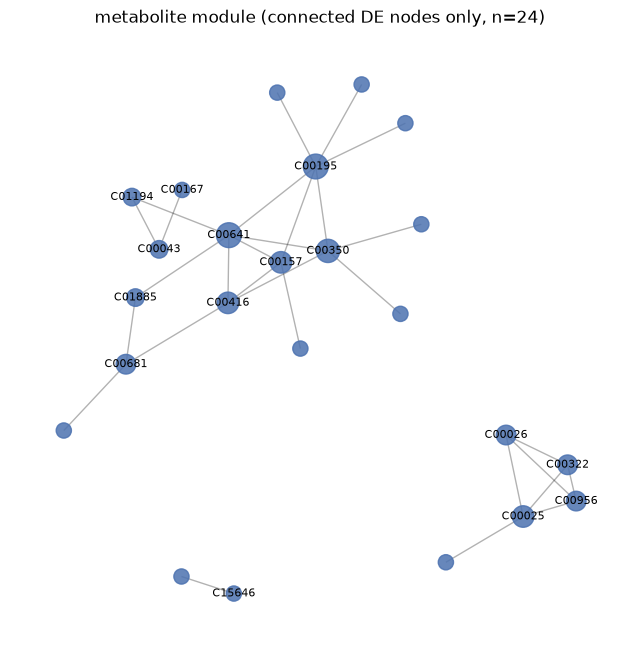

In [16]:
import matplotlib.pyplot as plt

PLOT_LAYER = "metabolite"   # change to "transcriptome" or "metabolite" to look at a different layer

G = graphs[PLOT_LAYER]
seed_nodes = module_seed_nodes[PLOT_LAYER]
sub = G.subgraph(seed_nodes).copy()
sub.remove_nodes_from(list(nx.isolates(sub)))   # drop singletons just for legibility

if sub.number_of_nodes() > 0:
    pos = nx.spring_layout(sub, seed=0, k=0.5)
    degrees = dict(sub.degree())
    sizes = [80 + 40 * degrees[n] for n in sub.nodes()]

    plt.figure(figsize=(8, 8))
    nx.draw_networkx_edges(sub, pos, alpha=0.3)
    nx.draw_networkx_nodes(sub, pos, node_size=sizes, node_color="#4C72B0", alpha=0.85)
    top_hubs = sorted(degrees, key=degrees.get, reverse=True)[:15]
    nx.draw_networkx_labels(sub, {n: pos[n] for n in top_hubs},
                             labels={n: n for n in top_hubs}, font_size=8)
    plt.title(f"{PLOT_LAYER} module (connected DE nodes only, n={sub.number_of_nodes()})")
    plt.axis("off")
    plt.show()
else:
    print("No connected subgraph to plot for this layer.")


## Step 3 — Enrichment: what biology is this?

We run functional enrichment (GO terms, KEGG/Reactome pathways) via [g:Profiler](https://biit.cs.ut.ee/gprofiler/) — no local database needed, one API call. We do this twice per gene-based layer (transcriptome, PPI):
- on the **raw DE list**, and
- on the **connected module only** (the DE nodes that formed a connected component above)

Comparing the two is informative: the module-only enrichment is usually cleaner/more specific, since it's filtered to genes that are network-validated as belonging together, not just individually differentially expressed.


In [17]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

def run_enrichment(gene_ids, label, sources=("GO:BP", "KEGG", "REAC")):
    if len(gene_ids) < 3:
        print(f"[{label}] too few genes ({len(gene_ids)}) — skipping")
        return None
    res = gp.profile(organism="hsapiens", query=list(gene_ids), sources=list(sources))
    if res.empty:
        print(f"[{label}] no significant terms")
        return res
    res = res.sort_values("p_value")
    print(f"[{label}] top terms:")
    display(res[["source", "name", "p_value", "term_size", "intersection_size"]].head(10))
    return res

GENE_LAYERS = ["transcriptome", "ppi"]

enrichment_results = {}
for layer in GENE_LAYERS:
    seed_nodes = module_seed_nodes[layer]
    connected = module_connected_nodes[layer]
    enrichment_results[f"{layer}_full_de_list"] = run_enrichment(seed_nodes, f"{layer} — full DE list")
    enrichment_results[f"{layer}_connected_module"] = run_enrichment(connected, f"{layer} — connected module only")


[transcriptome — full DE list] top terms:


,source,name,p_value,term_size,intersection_size
0,REAC,Eukaryotic Translation Elongation,9.847335e-57,94,55
1,REAC,Peptide chain elongation,8.959571e-55,90,53
2,REAC,Viral mRNA Translation,2.239036e-51,90,51
3,REAC,Eukaryotic Translation Termination,4.977200e-50,94,51
4,REAC,Selenocysteine synthesis,4.977200e-50,94,51
5,REAC,Nonsense Mediated Decay (NMD) independent of t...,2.174363e-49,96,51
6,REAC,Response of EIF2AK4 (GCN2) to amino acid defic...,1.387021e-47,102,51
7,REAC,Formation of a pool of free 40S subunits,1.387021e-47,102,51
8,REAC,Selenoamino acid metabolism,3.812570e-45,117,52
9,REAC,L13a-mediated translational silencing of Cerul...,6.679331e-45,112,51


[transcriptome — connected module only] top terms:


,source,name,p_value,term_size,intersection_size
0,GO:BP,cell cycle process,6.382184e-17,1290,62
1,GO:BP,mitotic cell cycle process,1.291608e-16,747,47
2,GO:BP,chromosome segregation,5.576076e-16,432,36
3,GO:BP,cell division,1.293766e-15,656,43
4,GO:BP,mitotic cell cycle,5.592648e-15,893,49
5,GO:BP,cytoskeleton organization,1.820449e-14,1534,64
6,GO:BP,nuclear chromosome segregation,3.574220e-14,324,30
7,GO:BP,cell cycle,2.829831e-13,1668,65
8,REAC,Peptide chain elongation,1.651250e-12,90,20
9,GO:BP,regulation of cell cycle process,1.868906e-12,728,41


[ppi — full DE list] top terms:


,source,name,p_value,term_size,intersection_size
0,GO:BP,DNA damage response,1.500343e-08,929,8
1,GO:BP,DNA metabolic process,2.666975e-08,998,8
2,GO:BP,DNA repair,1.585990e-07,622,7
3,GO:BP,cellular response to stress,3.865921e-06,1856,8
4,REAC,Homology Directed Repair,4.157655e-06,140,5
5,REAC,DNA Repair,4.463678e-06,329,6
6,REAC,DNA Double-Strand Break Repair,1.104224e-05,170,5
7,GO:BP,DNA replication,3.263021e-05,300,5
8,GO:BP,double-strand break repair,4.646642e-05,322,5
9,GO:BP,DNA recombination,6.845570e-05,348,5


[ppi — connected module only] too few genes (0) — skipping


## Step 4 — Save outputs for later notebooks

In [18]:
modules = {
    layer: {"seed_nodes": module_seed_nodes[layer], "connected_nodes": module_connected_nodes[layer]}
    for layer in LAYERS
}

with open(os.path.join(PROC_DIR, "modules.pkl"), "wb") as f:
    pickle.dump(modules, f)

for name, res in enrichment_results.items():
    if res is not None and not res.empty:
        res.to_csv(os.path.join(PROC_DIR, f"enrichment_{name}.csv"), index=False)

print("Saved modules and enrichment tables to", PROC_DIR)


Saved modules and enrichment tables to ./processed


---
**Next:** open `03_bridging.ipynb` to connect the protein module and the metabolite module, and see whether they converge on the same biology — and whether any of it looks targetable.

**Optional:** `04_disease_modules_optional.ipynb` picks up the module-significance question we skipped here, and extends it to compare your module against two reference diseases.


**Workshop notebooks:** [01 — Matching & Loading](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/01_matching_and_loading.ipynb)  &nbsp;·&nbsp; **02 — Overlay & Enrichment(you are here)** &nbsp;·&nbsp;[03 — Bridging](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/03_bridging.ipynb)&nbsp;·&nbsp;[04 — Disease Modules (optional)](https://colab.research.google.com/github/marlene-grabner/NetworkMedicine_Workshop/blob/main/04_disease_modules_optional.ipynb)